### Short Study on Libration, Resonance Angles, 2BRs, 3BRs, and Stability
#### Dan Chen, May 2026

#### Imports & Setup

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import rebound
import reboundx
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 9,
    "lines.linewidth": 1.5,
})

#### The Pendulum as a Model of Resonance

A planet pair near a $p{:}q$ mean-motion resonance behaves like a (nonlinear) pendulum.
The resonance angle $\phi$ obeys (in the pendulum limit):

$$\ddot{\phi} = -\omega_0^2 \sin\phi$$

where $\omega_0$ sets the libration frequency and depends on the parameters of the orbits (mass, eccentricity, resonance order). For a pendulum, $\omega_0 = \sqrt{\dfrac{g}{l}}$.

**Two regimes:**
- Libration ($\phi$ oscillates): the system is inside the resonance separatrix.
  The angle rocks back and forth around an equilibrium (could be 0° or 180° or other depending on resonance type).
- Circulation ($\phi$ increases/decreases monotonically): the system is outside the resonance.

The separatrix (the boundary between these) corresponds to energy $E = \omega_0^2$
($\dot{\phi}=0$ at the unstable equilibrium at $\phi = \pi$).

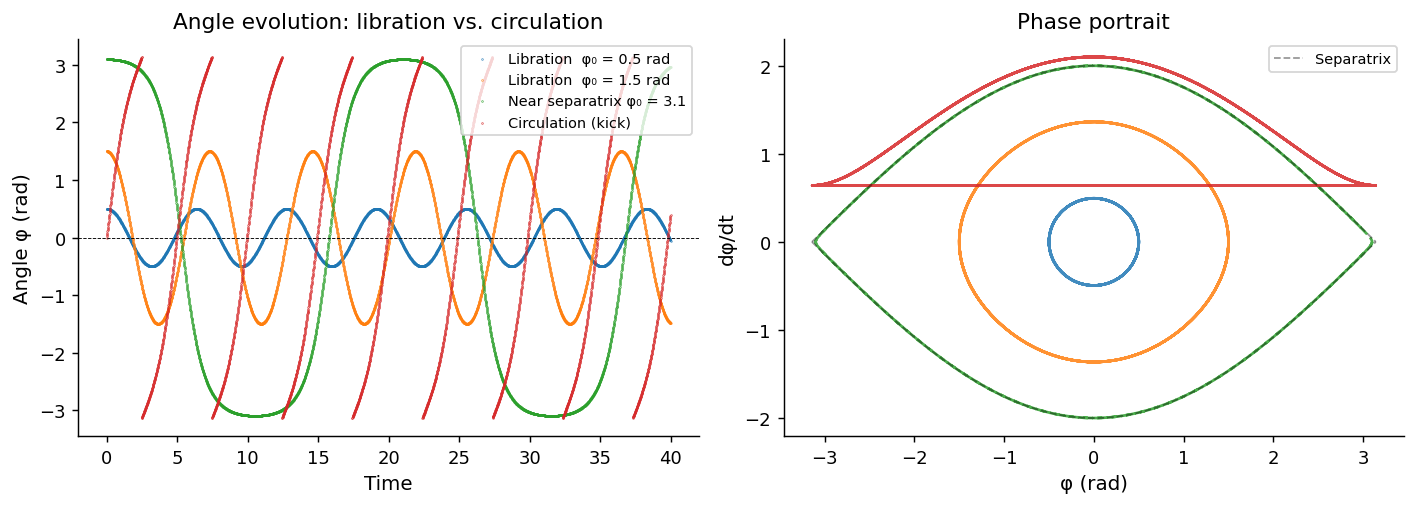

In [54]:
def pendulum_rhs(t, y, omega0):
    phi, dphi = y
    return [dphi, -omega0**2 * np.sin(phi)]

omega0 = 1.0
t_span = (0, 40)
t_eval = np.linspace(*t_span, 4000)

# Initial conditions: amplitude in phi0, dphi0
cases = [
    (0.5,  0.0, "Libration  φ₀ = 0.5 rad",  "C0", "-"),
    (1.5,  0.0, "Libration  φ₀ = 1.5 rad",  "C1", "-"),
    (3.1,  0.0, "Near separatrix φ₀ = 3.1", "C2", "--"),
    (0.0, 2.1,  "Circulation (kick)",         "C3", "-."),
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax_t, ax_pp = axes

for phi0, dphi0, label, color, ls in cases:
    sol = solve_ivp(pendulum_rhs, t_span, [phi0, dphi0],
                    args=(omega0,), t_eval=t_eval, max_step=0.02)
    phi = sol.y[0]
    # Wrap to (-pi, pi] for display
    phi_wrapped = (phi + np.pi) % (2 * np.pi) - np.pi
    ax_t.scatter(sol.t, phi_wrapped, color=color, s=0.1, label=label, alpha=0.85)
    ax_pp.plot(phi_wrapped, sol.y[1], color=color, ls=ls, alpha=0.85)

ax_t.axhline(0, color="k", lw=0.5, ls="--")
ax_t.set_xlabel("Time")
ax_t.set_ylabel("Angle φ (rad)")
ax_t.set_title("Angle evolution: libration vs. circulation")
ax_t.legend(fontsize=8, loc="upper right")

ax_pp.set_xlabel("φ (rad)")
ax_pp.set_ylabel("dφ/dt")
ax_pp.set_title("Phase portrait")
# Draw separatrix
phi_sep = np.linspace(-np.pi, np.pi, 500) # formula derived from Hamiltonian of a simple pendulum
dphi_sep = 2 * omega0 * np.cos(phi_sep / 2)
ax_pp.plot(phi_sep,  dphi_sep, "k--", lw=1.0, alpha=0.4, label="Separatrix")
ax_pp.plot(phi_sep, -dphi_sep, "k--", lw=1.0, alpha=0.4)
ax_pp.legend(fontsize=8)

plt.tight_layout()
plt.show()

#### Damped pendulum as an analog of disk eccentricity damping

During disk-driven migration the protoplanetary disk provides two main torques:
- Semimajor-axis damping (migration): drives $\dfrac{\dot{a}}{a} = -\dfrac{1}{\tau_a}$
- Eccentricity damping: drives $\dfrac{\dot{e}}{e} = -\dfrac{1}{\tau_e}$

For a pendulum, damping acts as friction based on $\dot{\phi}$:

$$\ddot{\phi} = -\omega_0^2 \sin\phi - 2\gamma\,\dot{\phi}$$

Three regimes:
| Regime | Condition | Outcome |
|--------|-----------|---------|
| Underdamped | $\gamma < \omega_0$ | Libration with shrinking amplitude |
| Critically damped | $\gamma = \omega_0$ | Fastest approach to equilibrium |
| Overdamped | $\gamma > \omega_0$ | No oscillation; slow exponential approach |

In disk migration models with $e$ damping, $\gamma \propto 1/\tau_e$ which is how libration amplitudes can decrease after chaotic formation.

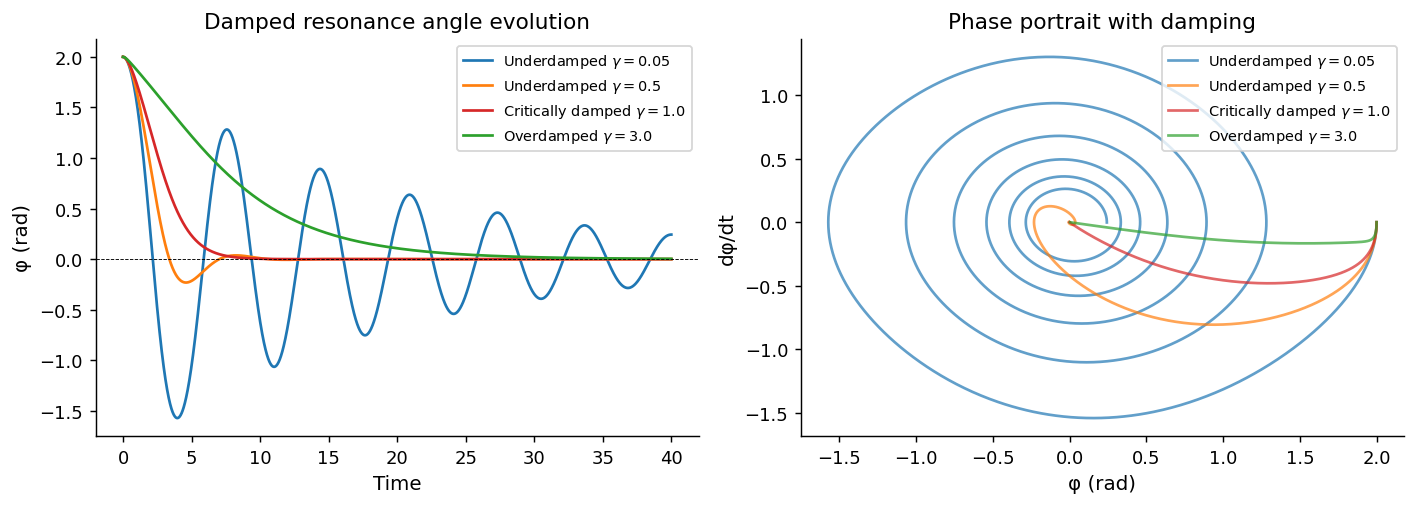

In [29]:
def damped_pendulum(t, y, omega0, gamma):
    phi, dphi = y
    return [dphi, -omega0**2 * np.sin(phi) - 2*gamma*dphi]

omega0 = 1.0
phi0, dphi0 = 2.0, 0.0
t_eval = np.linspace(0, 40, 5000)

gamma_cases = [
    (0.05, "Underdamped $\gamma=0.05$", "C0"),
    (0.5,  "Underdamped $\gamma=0.5$",  "C1"),
    (1.0,  "Critically damped $\gamma=1.0$", "C3"),
    (3.0,  "Overdamped $\gamma=3.0$",   "C2"),
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for gamma, label, color in gamma_cases:
    sol = solve_ivp(damped_pendulum, (0, 40), [phi0, dphi0],
                    args=(omega0, gamma), t_eval=t_eval, max_step=0.02)
    phi_w = (sol.y[0] + np.pi) % (2*np.pi) - np.pi
    axes[0].plot(sol.t, phi_w, color=color, label=label)
    axes[1].plot(phi_w, sol.y[1], color=color, label=label, alpha=0.7)

axes[0].axhline(0, color="k", lw=0.5, ls="--")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("φ (rad)")
axes[0].set_title("Damped resonance angle evolution")
axes[0].legend(fontsize=8)

axes[1].set_xlabel("φ (rad)")
axes[1].set_ylabel("dφ/dt")
axes[1].set_title("Phase portrait with damping")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

#### The double pendulum as an analog to coupled resonances

The double pendulum introduces chaos through coupling between two degrees of freedom, analogous to how multiple resonance angles in a 3-planet system can interact.

In a resonant chain, the 2-body angles $\phi_{12}$ and $\phi_{23}$ are coupled through
the Laplace (3-body) angle (example form):

$$\phi_L = \phi_{12} - \phi_{23} = p\lambda_1 - (p+q)\lambda_2 + q\lambda_3$$

Can be stable or chaotic based on energy. A 3-planet chain can have the Laplace angle librating even when individual 2-body angles are circulating.

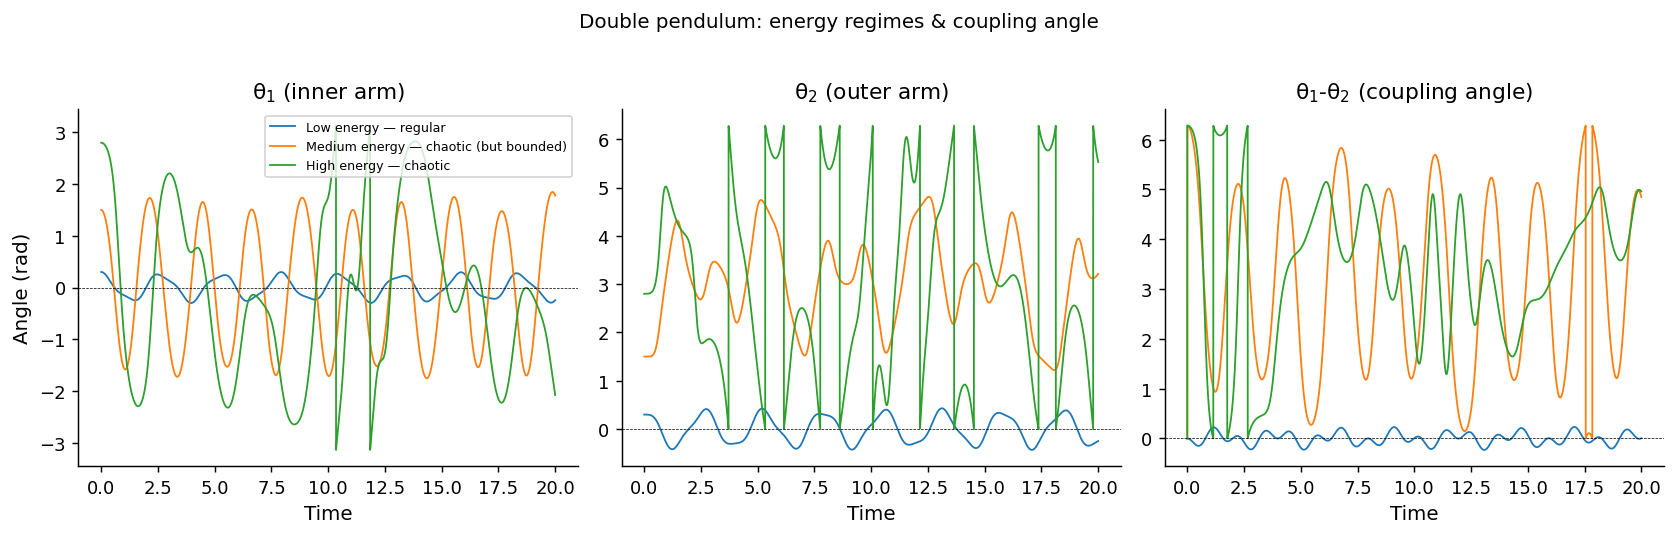

In [167]:
def double_pendulum_rhs(t, y, l1, l2, m1, m2, g=9.81):
    th1, w1, th2, w2 = y
    c = np.cos(th1 - th2)
    s = np.sin(th1 - th2)
    denom1 = (m1 + m2) * l1 - m2 * l1 * c**2
    denom2 = (l2 / l1) * denom1

    dw1 = (m2 * l1 * w1**2 * s * c
           + m2 * g * np.sin(th2) * c
           + m2 * l2 * w2**2 * s
           - (m1 + m2) * g * np.sin(th1)) / denom1

    dw2 = (-m2 * l2 * w2**2 * s * c
           + (m1 + m2) * g * np.sin(th1) * c
           - (m1 + m2) * l1 * w1**2 * s
           - (m1 + m2) * g * np.sin(th2)) / denom2

    return [w1, dw1, w2, dw2]

t_eval = np.linspace(0, 20, 8000)

dp_cases = [ 
    # initial θ1, ω1, θ2, ω2 (angles & angular vel)
    (0.3, 0, 0.3, 0.0,  "Low energy — regular",    "C0"),
    (1.5, 0.0, 1.5, 0.0,  "Medium energy — chaotic (but bounded)", "C1"),
    (2.8, 0.0, 2.8, 0.0,  "High energy — chaotic",   "C2"),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for th10, w10, th20, w20, label, color in dp_cases:
    y0 = [th10, w10, th20, w20]
    sol = solve_ivp(double_pendulum_rhs, (0, 20), y0,
                    args=(1.0, 1.0, 1.0, 1.0), t_eval=t_eval, max_step=0.005,
                    method="RK45", rtol=1e-9, atol=1e-10)
    th1 = sol.y[0]
    th2 = sol.y[2]
    # Coupling angle: th1 - th2 (analogous to Laplace angle)
    phi_L = (th1 - th2 + np.pi) % (2*np.pi) - np.pi

    axes[0].plot(sol.t, (th1+np.pi)%(2*np.pi)-np.pi, color=color, lw=1, label=label)
    
    if color != "C0": # outer arm case and coupling angle
        axes[1].plot(sol.t, ((th2+np.pi)%(2*np.pi)+np.pi)%(2*np.pi), color=color, lw=1, label=label)
        axes[2].plot(sol.t, (phi_L+2*np.pi)%(2*np.pi), color=color, lw=1, label=label)
    else:
        axes[1].plot(sol.t, (th2+np.pi)%(2*np.pi)-np.pi, color=color, lw=1, label=label)
        axes[2].plot(sol.t, phi_L, color=color, lw=1, label=label)

for ax, title in zip(axes, ["θ$_1$ (inner arm)", "θ$_2$ (outer arm)", "θ$_1$-θ$_2$ (coupling angle)"]):
    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.axhline(0, color="k", lw=0.4, ls="--")
axes[0].set_ylabel("Angle (rad)")
axes[0].legend(fontsize=7, loc="upper right")

plt.suptitle("Double pendulum: energy regimes & coupling angle",
             y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

#### Two-body resonance angles — analytic definition and REBOUND demo


The two-body resonance angle of planets in $p{:}q$ resonance is given by $$\theta = p \lambda_2 + q \lambda_1 - (p-q)\varpi_1$$
(Li, 2025) where $\lambda_i=M_i + \varpi_i$ and $\varpi_i$ are the mean longitude and longitude of pericenter for planet $i$, respectively. 

For first-order MMRs ($p{+}1{:}p$), the two-body resonance angles is simply:

$$\phi_1 = (p+1)\lambda_2 - p\lambda_1 - \varpi_1$$
$$\phi_2 = (p+1)\lambda_2 - p\lambda_1 - \varpi_2.$$

Resonance is defined by libration of the resonance angle(s).

Below we set up a 2-planet system near 3:2 MMR and track the resonance angle.

Running in-resonance case...
Running off-resonance case...


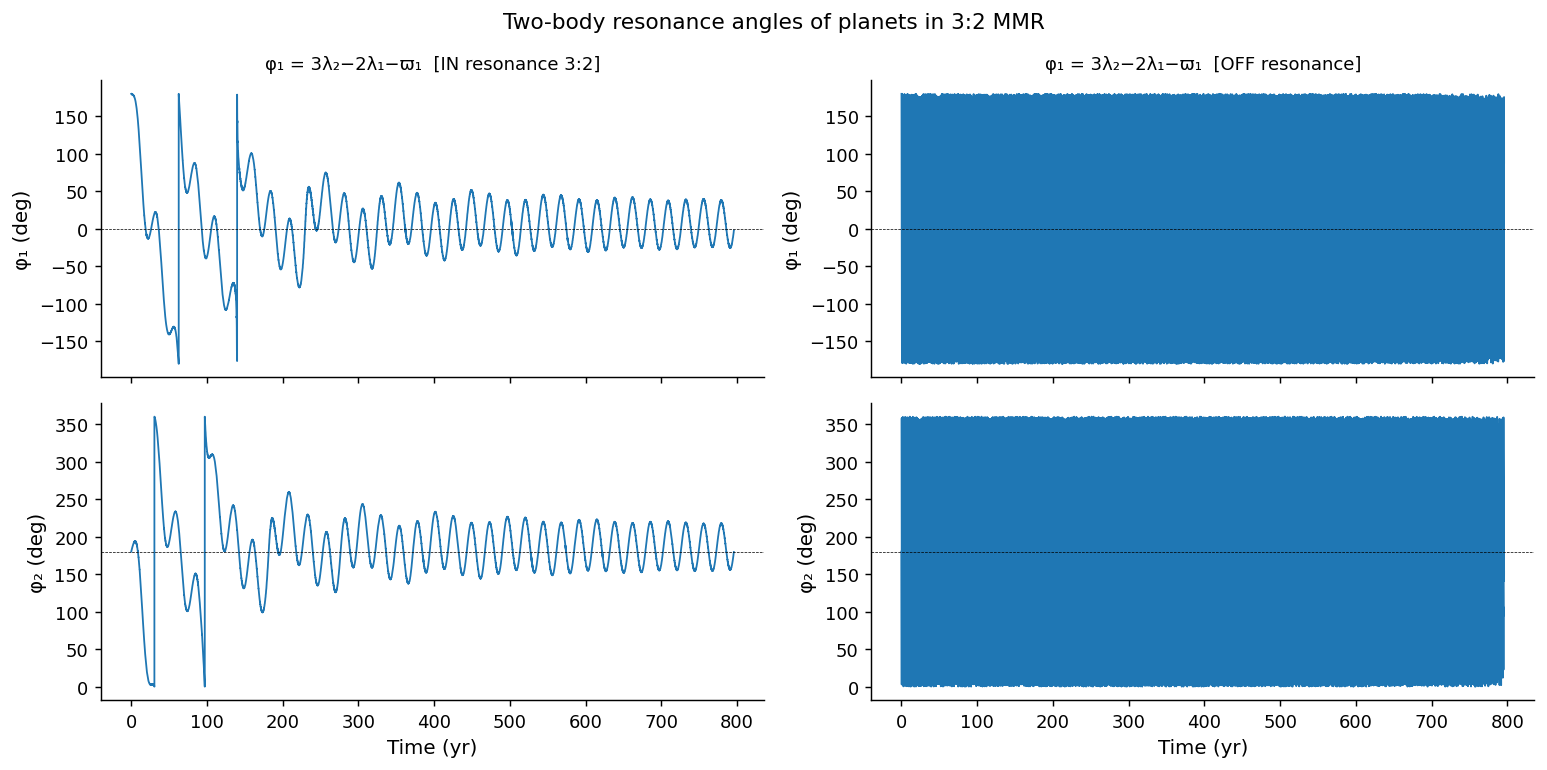

In [166]:
def run_2body_resonance(a1, a2, e1, e2, m1, m2, Norbits=5000, Nout=100000):
    """Run a 2-planet REBOUND sim and return resonance angle time series."""
    sim = rebound.Simulation()
    sim.G = 4 * np.pi**2 # Units: AU, Yr, M_sun
    sim.add(m=1.0) # star
    
    # Calculate Mean Longitudes (l) to satisfy the resonance
    l1 = 0.0
    l2 = np.pi / 3.0
    
    sim.add(m=m1, a=a1, e=e1, l=l1)
    sim.add(m=m2, a=a2, e=e2, l=l2)
    sim.move_to_com()
    sim.integrator = "whfast"
    ps = sim.particles
    sim.dt = 0.05 * ps[1].P

    # Adding damping so they stay in resonance    
    rebx = reboundx.Extras(sim)
    mof = rebx.load_force("modify_orbits_forces")
    rebx.add_force(mof)

    # Set timescales (negative value = damping/inward migration)
    tau_a = -1e5 
    tau_e = -1e3
    
    # a damping here is only applied to the outer planet
    ps[2].params["tau_a"] = tau_a
    # e damping on all planets
    for i in range(1, 3):
        ps[i].params["tau_e"] = tau_e

    times = np.linspace(0, Norbits * sim.particles[1].P, Nout)
    phi1_arr = np.zeros(Nout)
    phi2_arr = np.zeros(Nout)

    for i, t in enumerate(times):
        sim.integrate(t)
        p1 = sim.particles[1]
        p2 = sim.particles[2]
        lam1 = p1.l   # mean longitude
        lam2 = p2.l
        pom1 = p1.pomega
        pom2 = p2.pomega
        # 3:2 resonance angles: phi = 3*lam2 - 2*lam1 - pomega
        phi1 = 3*lam2 - 2*lam1 - pom1
        phi2 = 3*lam2 - 2*lam1 - pom2
        phi1_arr[i] = (phi1 + np.pi) % (2*np.pi) - np.pi
        phi2_arr[i] = (phi2 + np.pi) % (2*np.pi) - np.pi

    times_yr = times / (2*np.pi)  # convert to years
    return times_yr, phi1_arr, phi2_arr

# a2/a1 for exact 3:2: (3/2)^(2/3) ≈ 1.310
a1 = 1.0
a2_res = a1 * (3/2)**(2/3)
a2_nonres = a1 * 1.45  # off resonance
ecc = 0.05
m_p = 3e-5 # planet mass (~10 Earth masses)

print("Running in-resonance case...")
t_r, phi1_r, phi2_r = run_2body_resonance(a1, a2_res, ecc, ecc, m_p, m_p)
print("Running off-resonance case...")
t_n, phi1_n, phi2_n = run_2body_resonance(a1, a2_nonres, ecc, ecc, m_p, m_p)

fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex="col")

for ax, phi, title, color in zip(
    axes[0],
    [phi1_r, phi1_n],
    ["φ₁ = 3λ₂−2λ₁−ϖ₁  [IN resonance 3:2]",
     "φ₁ = 3λ₂−2λ₁−ϖ₁  [OFF resonance]"],
    ["C0", "C0"]
):
    ax.plot(t_r if "IN" in title else t_n, phi * 180/np.pi, color=color, lw=1)
    ax.axhline(0, color="k", lw=0.4, ls="--")
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("φ₁ (deg)")

for ax, phi, t, color in zip(
    axes[1],
    [phi2_r, phi2_n],
    [t_r, t_n],
    ["C0", "C0"]
):
    ax.plot(t, (phi * 180/np.pi + 360)%360, color=color, lw=1)
    ax.axhline(180, color="k", lw=0.4, ls="--")
    ax.set_ylabel("φ₂ (deg)")
    ax.set_xlabel("Time (yr)")

plt.suptitle("Two-body resonance angles of planets in 3:2 MMR", fontsize=12)
plt.tight_layout()
plt.show()

#### Three-body (a.k.a. Laplace) resonance angles

For three planets with mean longitudes $\lambda_1, \lambda_2, \lambda_3$ and a first-order chain of
$(p+1){:}p$ and $(q+1){:}q$ resonances, the three-body angle is:

$$\phi = p\lambda_1 - (p+q+1)\lambda_2 + (q+1)\lambda_3$$

which simplifies (for 3:2 / 3:2) to:

$$\phi = 2\lambda_1 - 5\lambda_2 + 3\lambda_3$$

This is divided by $\gcd \{q-1, p+q-1, p-2\}$ which is usually 1 (see Hadden, 2026).

This combination cancels the pericenter longitudes and captures the collective phase relationship among all three planets.

Note that $\phi$ can librate even when individual two-body angles circulate. In TRAPPIST-1, the observed 3BRs keep the chain stable over billions of years (Tamayo et al. 2017).

For the b/c/d triplet in TRAPPIST-1 the three-body angle takes the same form as an 8:5:3 combination because of the higher-order resonances between b/c and c/d.

Running 3-planet resonant chain...


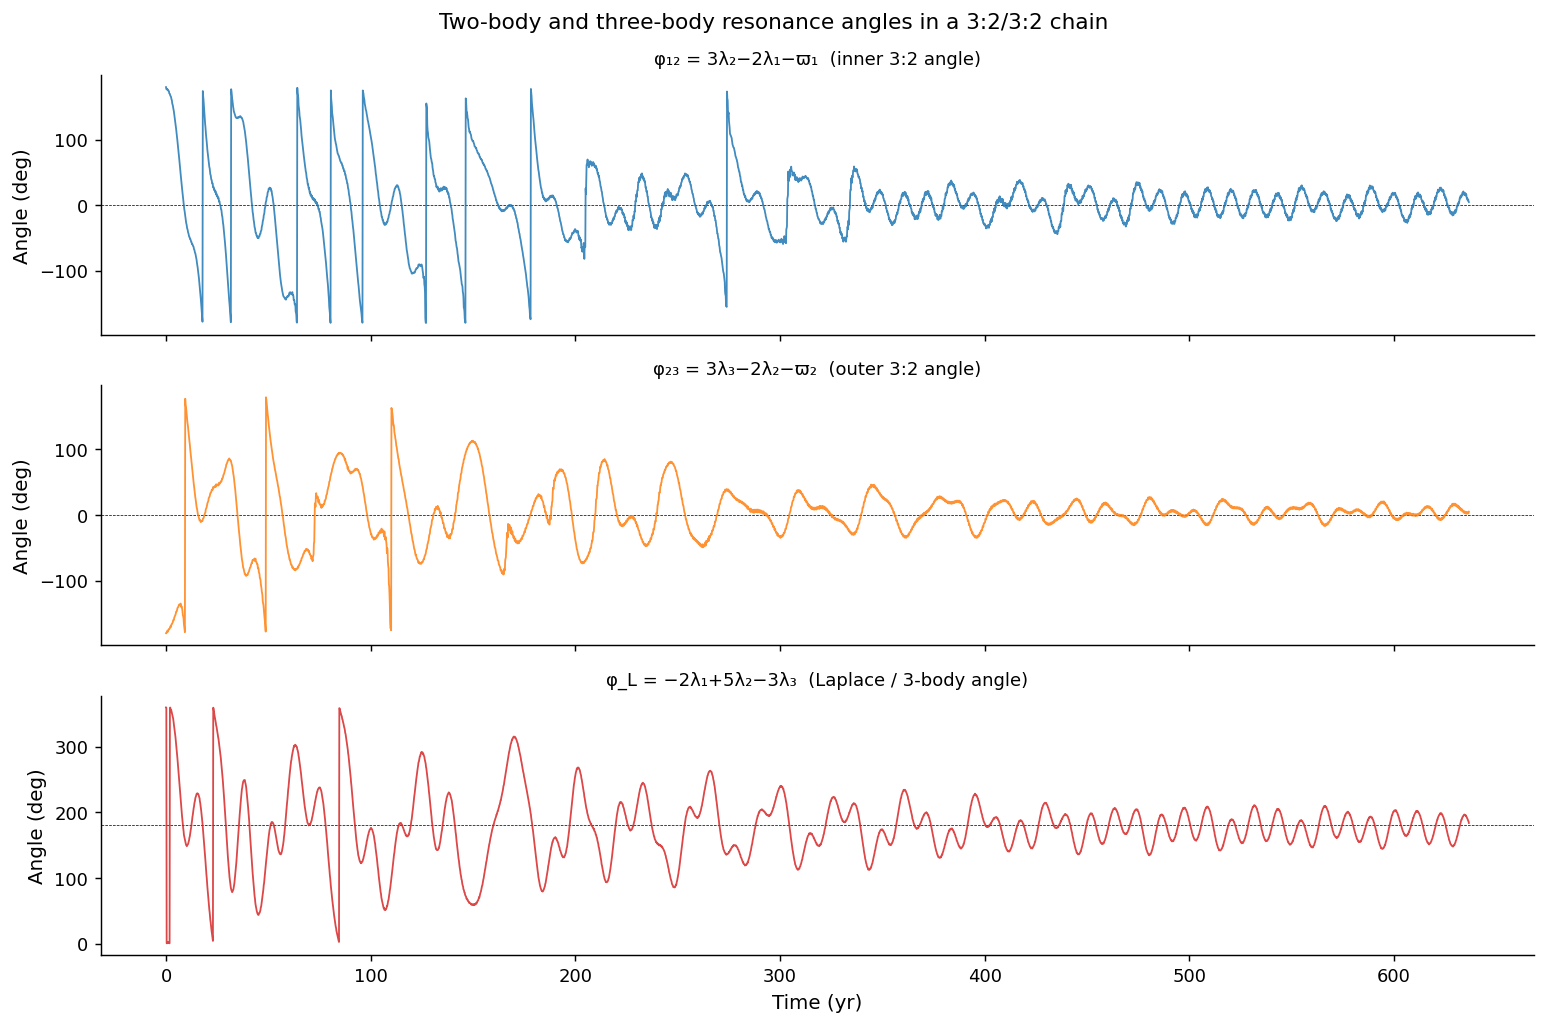

In [168]:
def run_3body_resonance(a1, a2, a3, e1, e2, e3, m1, m2, m3, Norbits=500, Nout=5000, damping=True):
    """Run 3-planet REBOUND sim; return 2-body and Laplace angles."""
    sim = rebound.Simulation()
    sim.G = 4 * np.pi**2 # Units: AU, Yr, M_sun
    sim.add(m=1.0)
    
    # Calculate Mean Longitudes (l) to satisfy the resonance
    l1 = 0.0
    l2 = np.pi / 3.0
    l3 = (np.pi + 2*l2) / 3.0
    
    sim.add(m=m1, a=a1, e=e1, l=l1)
    sim.add(m=m2, a=a2, e=e2, l=l2)
    sim.add(m=m3, a=a3, e=e3, l=l3)
    sim.move_to_com()
    sim.integrator = "whfast"
    sim.dt = 0.03 * sim.particles[1].P

    P1 = sim.particles[1].P
    times = np.linspace(0, Norbits * P1, Nout)

    phi12 = np.zeros(Nout)  # 3:2 angle for inner pair
    phi23 = np.zeros(Nout)  # 3:2 angle for outer pair
    phi_L = np.zeros(Nout)  # Laplace angle

    ps = sim.particles
    
    if damping:
        # Adding damping so they stay in resonance    
        rebx = reboundx.Extras(sim)
        mof = rebx.load_force("modify_orbits_forces")
        rebx.add_force(mof)

        # Set timescales (negative value = damping/inward migration)
        tau_a = -1e5 
        tau_e = -1e3
        
        # a damping here is only applied to the outer planet
        ps[3].params["tau_a"] = tau_a
        # e damping on all planets
        for i in range(1, 4):
            ps[i].params["tau_e"] = tau_e
    
    for i, t in enumerate(times):
        sim.integrate(t)
        l1, l2, l3 = ps[1].l, ps[2].l, ps[3].l
        pom1, pom2, pom3 = ps[1].pomega, ps[2].pomega, ps[3].pomega
        # 3:2 resonance angles
        ph12 = 3*l2 - 2*l1 - pom1
        ph23 = 3*l3 - 2*l2 - pom2
        # Laplace angle (cancels pericenter)
        phL  = -2*l1 + 5*l2 - 3*l3   # = (3l2-2l1) - (3l3-2l2)
        phi12[i] = (ph12 + np.pi) % (2*np.pi) - np.pi
        phi23[i] = (ph23 + np.pi) % (2*np.pi) - np.pi
        phi_L[i] = (phL  + np.pi) % (2*np.pi) - np.pi

    times_yr = times / (2*np.pi)
    return times_yr, phi12, phi23, phi_L

# 3:2 / 3:2 chain  (a2/a1 = a3/a2 = (3/2)^(2/3))
a1 = 1.0
ratio = (3/2)**(2/3)
a2 = a1 * ratio
a3 = a2 * ratio
ecc = 0.05

m_p = 1e-4 # planet mass

print("Running 3-planet resonant chain...")
t, phi12, phi23, phi_L = run_3body_resonance(
    a1, a2, a3,
    ecc, ecc, ecc,
    m_p, m_p, m_p,
    Norbits=4000, Nout=4000, damping=True
)

phi_L = (phi_L + 2*np.pi) % (2*np.pi)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

colors = ["C0", "C1", "C3"]
data   = [phi12, phi23, phi_L]
labels = ["φ₁₂ = 3λ₂−2λ₁−ϖ₁  (inner 3:2 angle)",
          "φ₂₃ = 3λ₃−2λ₂−ϖ₂  (outer 3:2 angle)",
          "φ_L = −2λ₁+5λ₂−3λ₃  (Laplace / 3-body angle)"]

for ax, d, label, color in zip(axes, data, labels, colors):
    if color == "C3": # Laplace 
        ax.axhline(180, color="k", lw=0.4, ls="--")
    else:
        ax.axhline(0, color="k", lw=0.4, ls="--")
    ax.plot(t, d * 180/np.pi, color=color, lw=1, alpha=0.85)
    ax.set_ylabel("Angle (deg)")
    ax.set_title(label, fontsize=10)

axes[-1].set_xlabel("Time (yr)")
plt.suptitle("Two-body and three-body resonance angles in a 3:2/3:2 chain", fontsize=12)
plt.tight_layout()
plt.show()

#### Visualizing resonance angles on a circle

A clean way to distinguish libration from circulation is to plot resonance angles
on a polar plot:
- Libration points cluster in an arc ( libration island)
- Circulation: points spread uniformly around the full circle

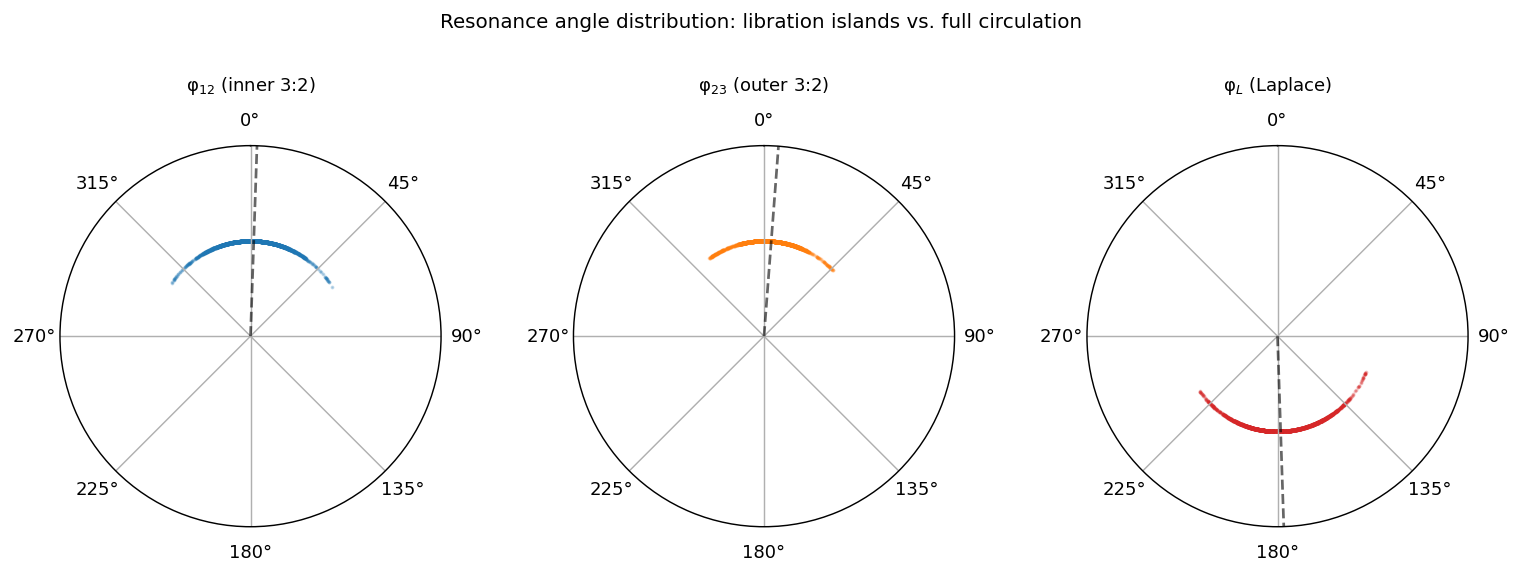

In [160]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4),
                         subplot_kw={"projection": "polar"})

datasets = [ 
    (phi12[int(len(phi12)/2):], "φ$_{12}$ (inner 3:2)", "C0"),
    (phi23[int(len(phi12)/2):], "φ$_{23}$ (outer 3:2)", "C1"),
    (phi_L[int(len(phi12)/2):], "φ$_L$ (Laplace)",   "C3"),
]

for ax, (phi, title, color) in zip(axes, datasets):
    # Scatter with alpha so density is visible
    ax.scatter(phi, np.ones(len(phi)), s=1.2, alpha=0.25, color=color)
    ax.set_yticks([])
    ax.set_title(title, pad=12, fontsize=10)
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    
    # Mark the libration center
    center = np.median(phi)
    ax.axvline(center, color="k", lw=1.5, alpha=0.6, ls="--")

plt.suptitle("Resonance angle distribution: libration islands vs. full circulation",
             y=1.05, fontsize=11)
plt.tight_layout()
plt.show()

#### Libration amplitude as a diagnostic

The amplitude of libration can give insights to disk conditions at formation. Small libration amplitudes may imply strong eccentricity damping ($\gamma \gg \omega_0$).

Here we sweep over damping strength and measure the steady-state libration amplitude (recall that $\gamma\propto 1/\tau_e$, so this is analogous to scanning $\tau_e$ parameter space in disk migration simulations).


In [175]:
def libration_amplitude(gamma_vals, omega0=1.0, phi0=2.0, dphi0=0.0, t_end=200, dt=0.02):
    amps = []
    t_eval = np.arange(0, t_end, dt)
    settle = int(0.6 * len(t_eval))   # use latter 40% for amplitude measurement
    for gamma in gamma_vals:
        sol = solve_ivp(damped_pendulum, (0, t_end), [phi0, dphi0],
                        args=(omega0, gamma), t_eval=t_eval, max_step=dt)
        phi = (sol.y[0, settle:] + np.pi) % (2*np.pi) - np.pi
        amp = 0.5 * (phi.max() - phi.min())
        amps.append(amp * 180 / np.pi)
    return np.array(amps)

gamma_vals = np.logspace(-3, 1, 80)
amps = libration_amplitude(gamma_vals)

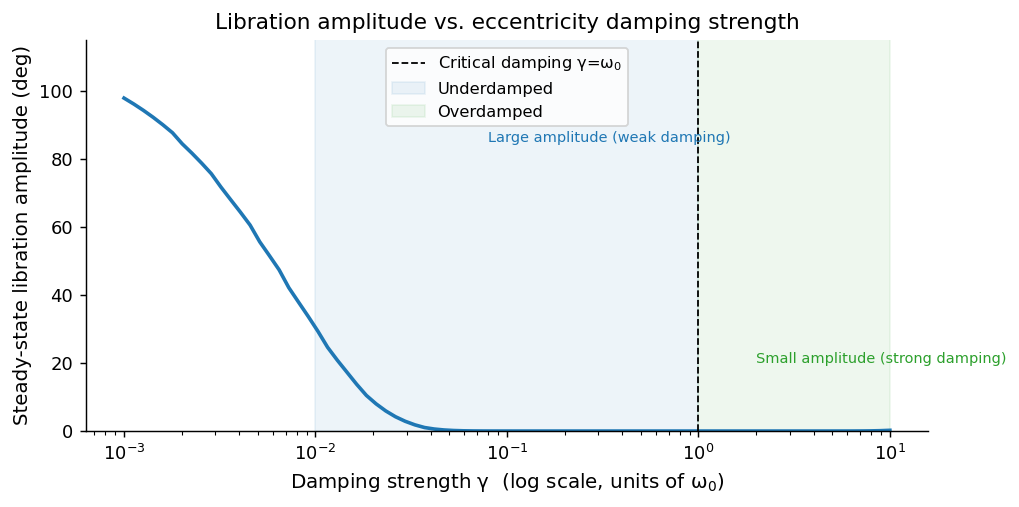

In [176]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(gamma_vals, amps, "C0", lw=2)
ax.axvline(1.0, color="k", ls="--", lw=1, label="Critical damping γ=ω$_0$")
ax.fill_betweenx([0, 200], 1e-2, 1.0, alpha=0.08, color="C0", label="Underdamped")
ax.fill_betweenx([0, 200], 1.0, 10,  alpha=0.08, color="C2", label="Overdamped")
ax.set_xlabel("Damping strength γ  (log scale, units of ω$_0$)")
ax.set_ylabel("Steady-state libration amplitude (deg)")
ax.set_title("Libration amplitude vs. eccentricity damping strength")
ax.set_ylim(0, 115)
ax.legend()
ax.text(0.08, 85, "Large amplitude (weak damping)", fontsize=8, color="C0")
ax.text(2.0,  20, "Small amplitude (strong damping)", fontsize=8, color="C2")
plt.tight_layout()
plt.show()